In [36]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import snorkel
from snorkel.labeling import labeling_function
from snorkel.labeling import labeling_function, PandasLFApplier
# Change the line below to this:
from snorkel.labeling.model import LabelModel

In [2]:
df_stocks_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/stock_view.csv")

In [3]:
df_macro_index_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/Index data/macro_indexs.csv")

In [26]:
df_final_no_spend = pd.read_csv(
    "/Users/Thomas/Desktop/Master Thesis/Data/df_final_no_spend.csv",
    dtype={
        "terminated": "str",
        "supplier_number": "str",
    },
)


# EDA for stocks

In [14]:
df_stocks_view.head()

,Unnamed: 0,BvD ID number,Company name Latin alphabet,Year,avg_vol,std_vol,max_vol,min_vol,vol_stability_score,vol_shock_ratio,...,Price_trends_52 weeks_%,market_beta_1y,Earnings_per_share_DKK,Book_value_per_share_DKK,Shares outstanding,Current_market_capitalisation_DKK,avg_closing_price,price_volatility_score,price_trend_slope,Risk level_stock_closing_price
0,0,AE0001327927,Rever Events L.L.C,2011,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Take caution
1,1,AE0001327927,Rever Events L.L.C,2012,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Take caution
2,2,AE0001327927,Rever Events L.L.C,2013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Take caution
3,3,AE0001327927,Rever Events L.L.C,2014,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Take caution
4,4,AE0001327927,Rever Events L.L.C,2015,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Take caution


In [10]:
df_stocks_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 30288 entries, 0 to 30287
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         30288 non-null  int64  
 1   BvD ID number                      30288 non-null  str    
 2   Company name Latin alphabet        30288 non-null  str    
 3   Year                               30288 non-null  int64  
 4   avg_vol                            1064 non-null   float64
 5   std_vol                            1060 non-null   float64
 6   max_vol                            1064 non-null   float64
 7   min_vol                            1064 non-null   float64
 8   vol_stability_score                1059 non-null   float64
 9   vol_shock_ratio                    1064 non-null   float64
 10  vol_trend_slope                    1059 non-null   float64
 11  Join_Year                          30288 non-null  int64  
 12  R

In [11]:
def clean_eda_columns(df):
    # Columns that should be numeric but are marked as 'str' in your schema
    cols_to_convert = ['Shares outstanding', 'Current_market_capitalisation_DKK']
    
    for col in cols_to_convert:
        if col in df.columns:
            # Remove dots/commas and handle 'n.a.'
            df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_stocks_view = clean_eda_columns(df_stocks_view)

## Statistical Percentiles

In [12]:
key_signals = [
    'vol_shock_ratio', 'vol_trend_slope', 'market_cap_volatility', 
    'market_beta_1y', 'price_volatility_score', 'price_trend_slope'
]

# Generate detailed statistics
stats_summary = df_stocks_view[key_signals].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])
print("--- Snorkel Threshold Reference Table ---")
print(stats_summary)

--- Snorkel Threshold Reference Table ---
       vol_shock_ratio  vol_trend_slope  market_cap_volatility  \
count      1064.000000      1059.000000            1060.000000   
mean         39.280018         0.009956               0.129503   
std         769.483901         0.182040               0.088402   
min           0.000000        -1.879210               0.000000   
10%           1.714298        -0.047217               0.048644   
25%           2.117816        -0.016506               0.071901   
50%           2.945807         0.004407               0.109410   
75%           5.162125         0.026830               0.158267   
90%          10.205265         0.062724               0.236132   
95%          19.492026         0.131530               0.298709   
99%         244.404761         0.803195               0.479828   
max       24696.395897         2.000000               0.683626   

       market_beta_1y  price_volatility_score  price_trend_slope  
count     1392.000000           

## Distribution Plots

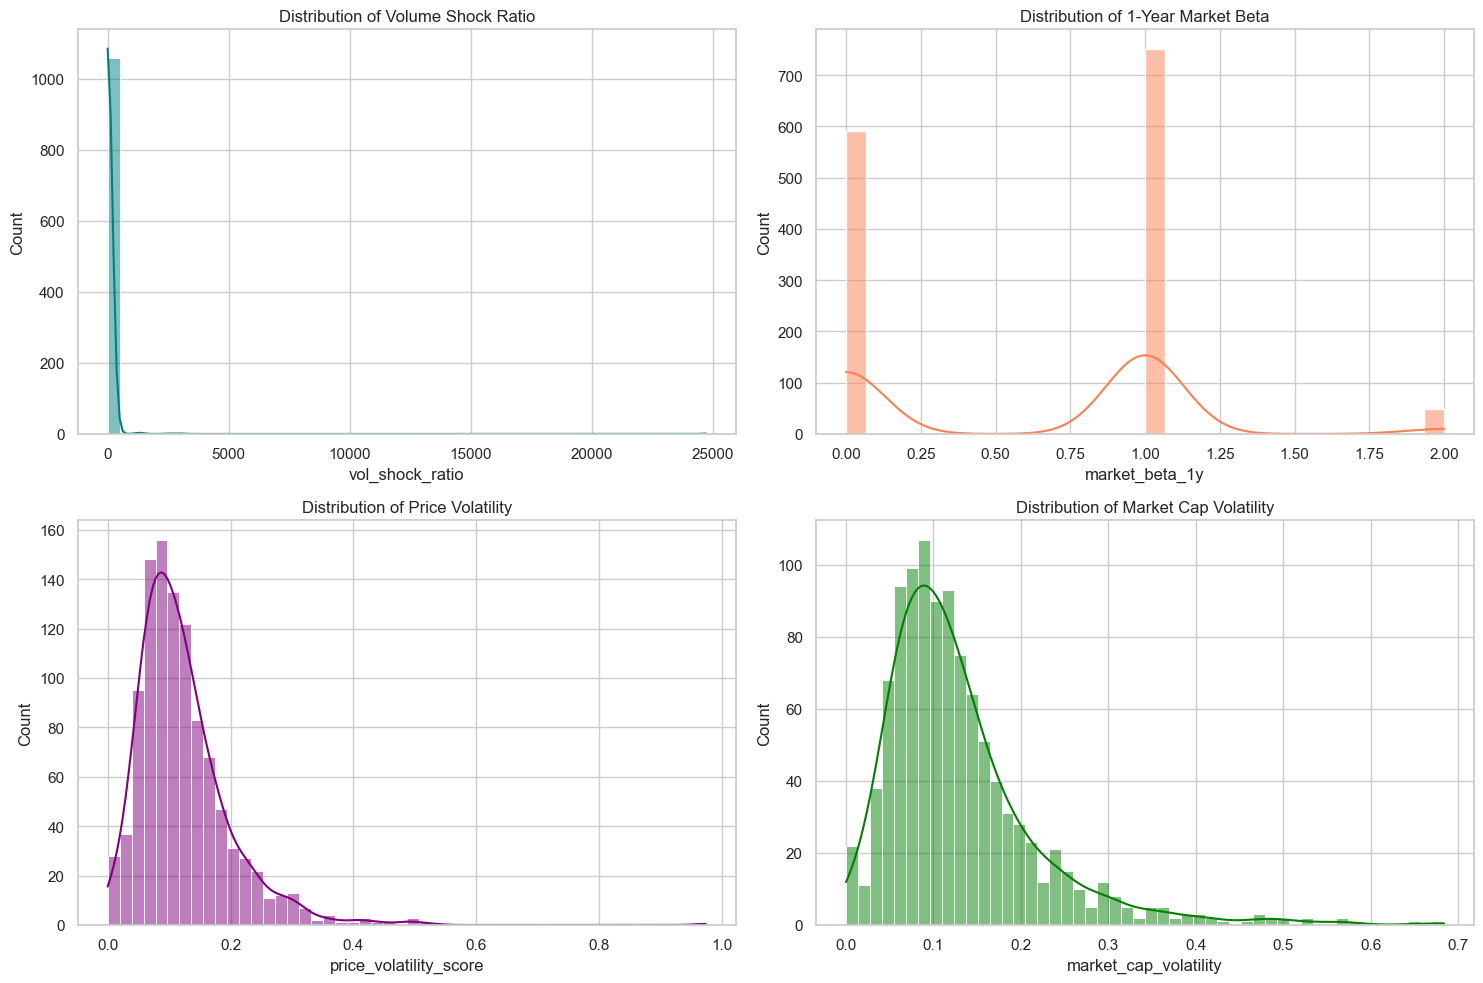

In [13]:
# Set visual style for a professional look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2)

# 1. Volume Shock (Sensitivity to events)
sns.histplot(df_stocks_view['vol_shock_ratio'].dropna(), bins=50, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Distribution of Volume Shock Ratio')

# 2. Market Beta (Systemic Risk)
sns.histplot(df_stocks_view['market_beta_1y'].dropna(), bins=30, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribution of 1-Year Market Beta')

# 3. Price Volatility (Market Sentiment)
sns.histplot(df_stocks_view['price_volatility_score'].dropna(), bins=50, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribution of Price Volatility')

# 4. Market Cap Volatility (Size Stability)
sns.histplot(df_stocks_view['market_cap_volatility'].dropna(), bins=50, kde=True, ax=axes[1,1], color='green')
axes[1,1].set_title('Distribution of Market Cap Volatility')

plt.tight_layout()
plt.show()

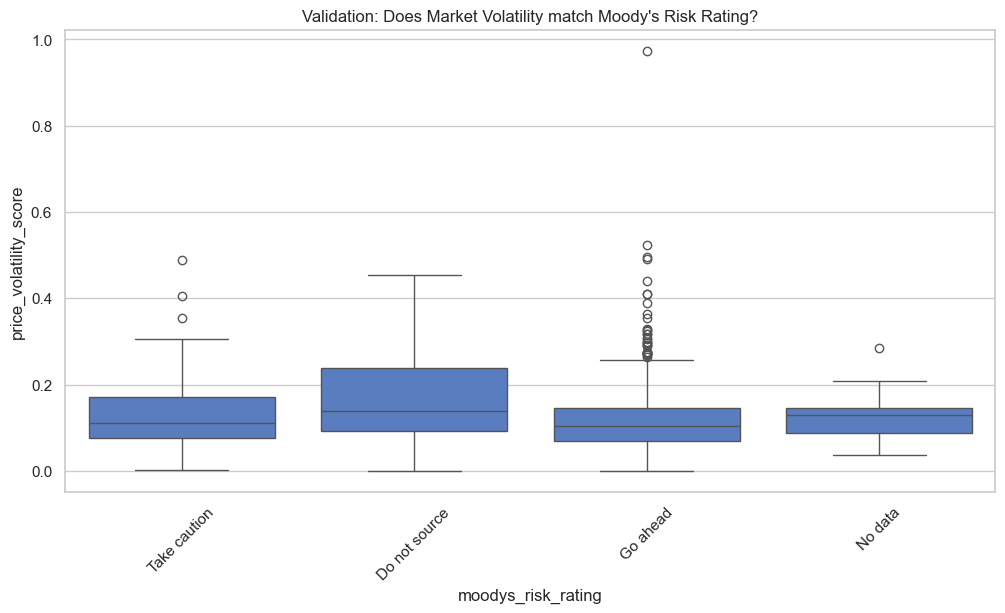

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_stocks_view, x='moodys_risk_rating', y='price_volatility_score')
plt.title('Validation: Does Market Volatility match Moody\'s Risk Rating?')
plt.xticks(rotation=45)
plt.show()

## Correlation heatmap

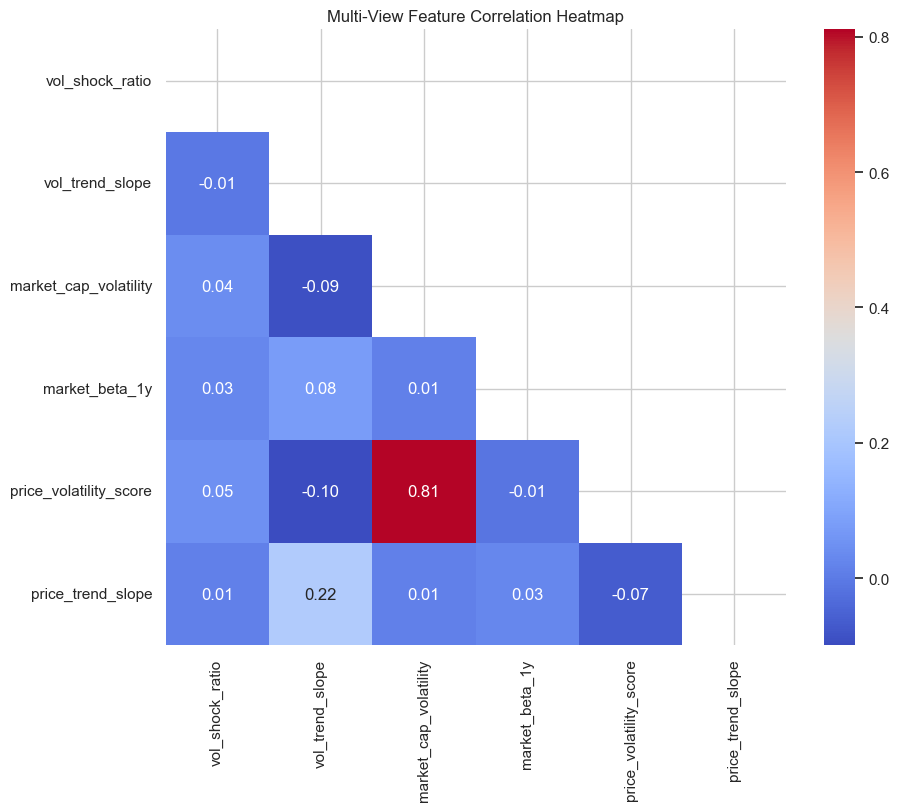

In [16]:
plt.figure(figsize=(10, 8))
corr = df_stocks_view[key_signals].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Only show bottom half
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f")
plt.title('Multi-View Feature Correlation Heatmap')
plt.show()

# EDA for macro indexes

In [18]:
df_macro_index_view.head()

,Unnamed: 0,Country,Code,LPI_Score,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,Year,PPI_Value
0,0,Afghanistan,AFG,1.211669,1.300000,1.100000,1.222220,1.250000,1.000000,1.375000,2007,NaN
1,1,Afghanistan,AFG,2.243160,2.223085,1.873596,2.244916,2.090449,2.365503,2.605503,2010,NaN
2,2,Afghanistan,AFG,2.297272,2.333617,2.003611,2.332182,2.162592,2.095155,2.795259,2012,NaN
3,3,Afghanistan,AFG,2.069573,2.163453,1.818951,1.986686,2.119709,1.847776,2.482138,2014,NaN
4,4,Afghanistan,AFG,1.948565,1.734900,1.807143,2.104431,1.919246,1.697024,2.382438,2018,NaN


In [17]:
df_macro_index_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1635 non-null   int64  
 1   Country                  1635 non-null   str    
 2   Code                     915 non-null    str    
 3   LPI_Score                1499 non-null   float64
 4   Customs                  1499 non-null   float64
 5   Infrastructure           1499 non-null   float64
 6   International_Shipments  1499 non-null   float64
 7   Logistics_Competence     1499 non-null   float64
 8   Tracking_Tracing         1499 non-null   float64
 9   Timeliness               1499 non-null   float64
 10  Year                     1635 non-null   int64  
 11  PPI_Value                945 non-null    float64
dtypes: float64(8), int64(2), str(2)
memory usage: 153.4 KB


## Statistical Thresholds

In [20]:
macro_cols = ['LPI_Score', 'Customs', 'Infrastructure', 'Logistics_Competence', 'PPI_Value']
stats_summary = df_macro_index_view[macro_cols].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95])

print("--- Macro Threshold Reference Table ---")
print(stats_summary)

--- Macro Threshold Reference Table ---
         LPI_Score      Customs  Infrastructure  Logistics_Competence  \
count  1499.000000  1499.000000     1499.000000           1499.000000   
mean      3.032795     2.835961        2.920345              2.995885   
std       0.611014     0.641267        0.734737              0.664998   
min       1.211669     1.300000        1.100000              1.250000   
5%        2.158762     1.941180        1.900000              2.072016   
10%       2.300000     2.083330        2.045943              2.184993   
25%       2.527419     2.334031        2.333331              2.454945   
50%       2.920566     2.695652        2.762986              2.870897   
75%       3.600000     3.395238        3.598421              3.600000   
90%       3.942263     3.800000        4.043594              3.966859   
95%       4.023764     3.917559        4.171078              4.100000   
max       4.300000     4.207790        4.600000              4.400000   

        PP

## Temporal Analysis

<Figure size 1500x1000 with 0 Axes>

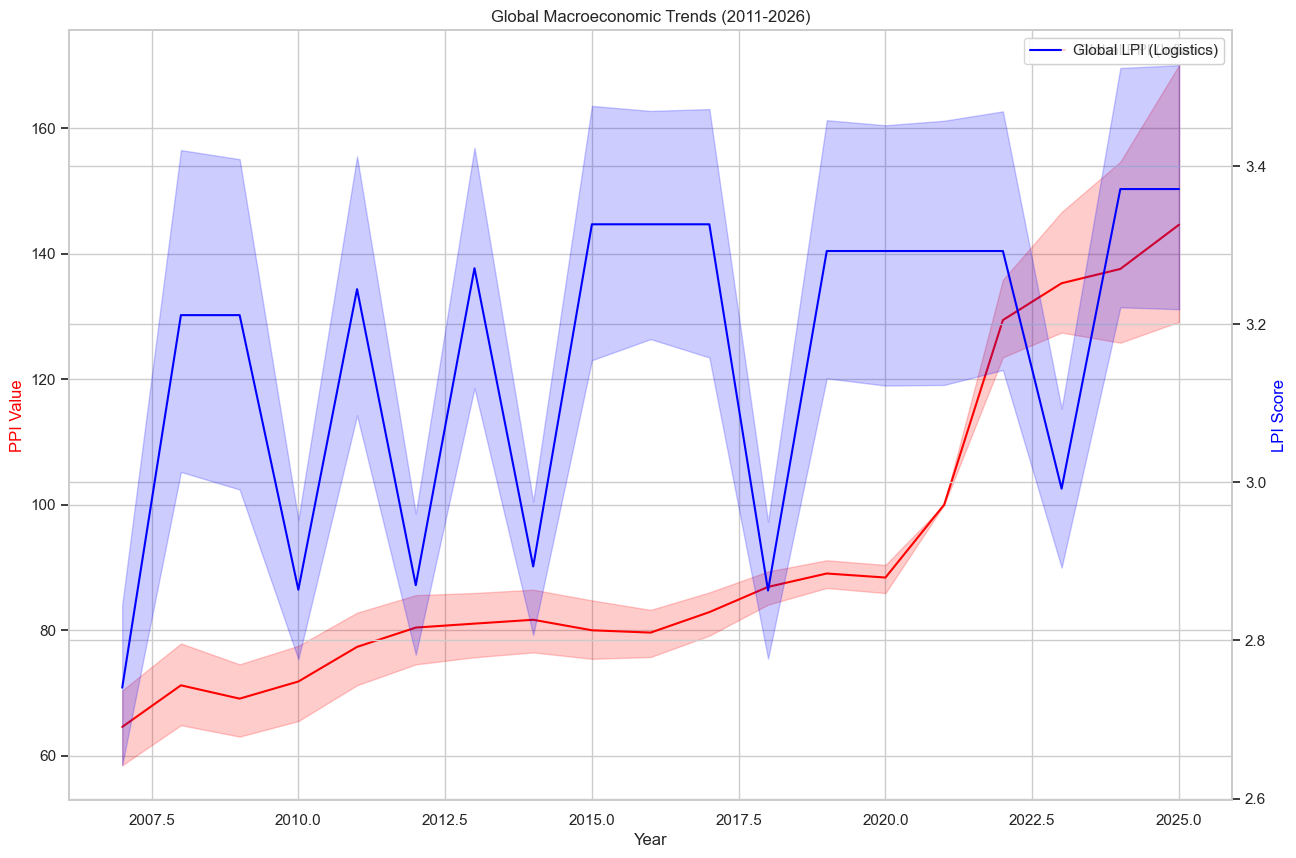

In [21]:
plt.figure()
# Plotting the global average PPI and LPI over time
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
sns.lineplot(data=df_macro_index_view, x='Year', y='PPI_Value', ax=ax1, color='red', label='Global PPI (Inflation)')
sns.lineplot(data=df_macro_index_view, x='Year', y='LPI_Score', ax=ax2, color='blue', label='Global LPI (Logistics)')

ax1.set_ylabel('PPI Value', color='red')
ax2.set_ylabel('LPI Score', color='blue')
plt.title('Global Macroeconomic Trends (2011-2026)')
plt.savefig('macro_temporal_trends.png')

## Correlation

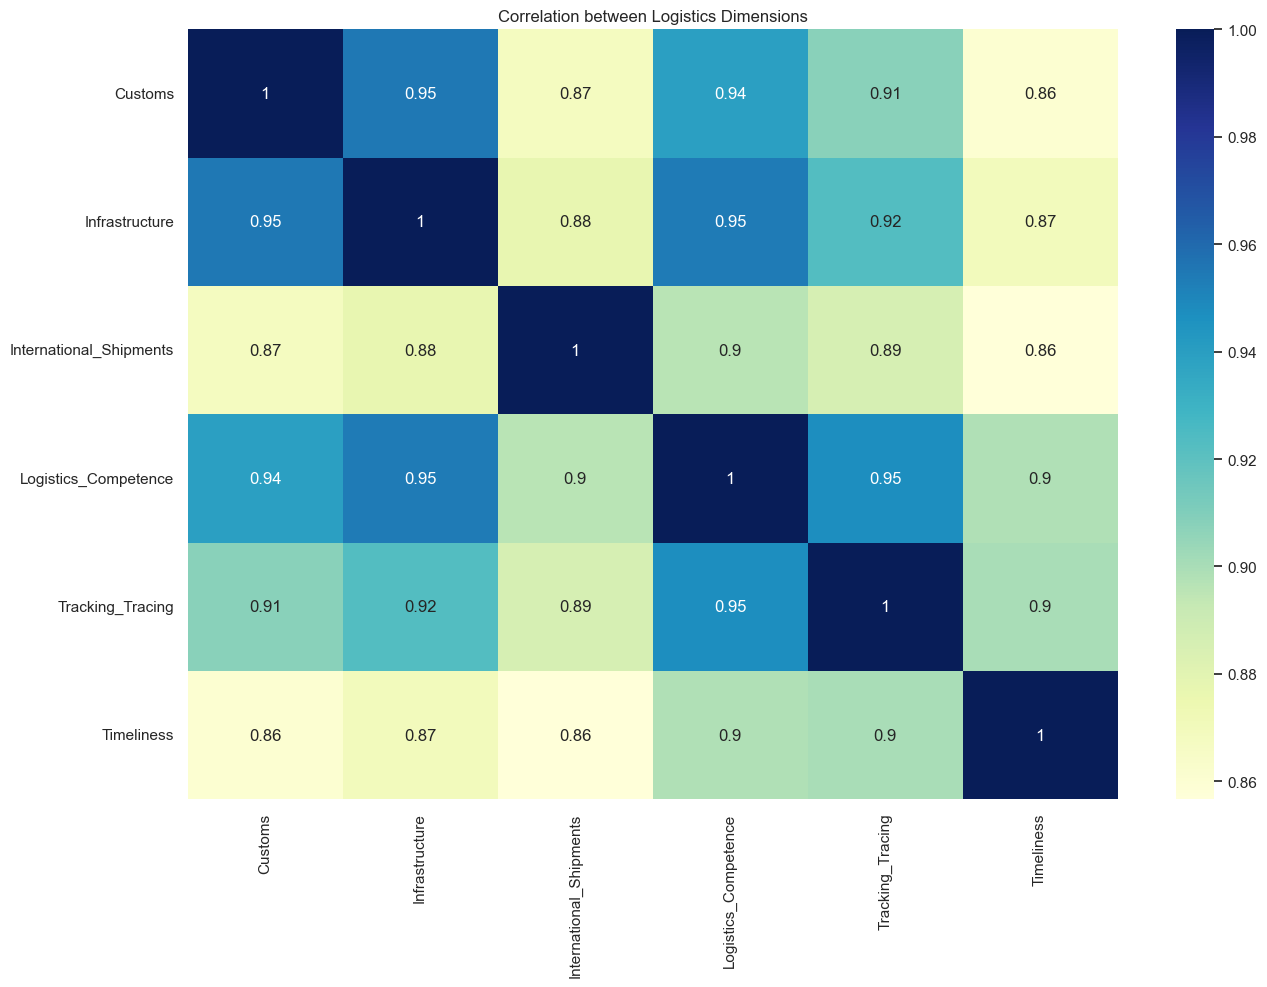

In [22]:
lpi_dimensions = ['Customs', 'Infrastructure', 'International_Shipments', 'Logistics_Competence', 'Tracking_Tracing', 'Timeliness']
plt.figure()
sns.heatmap(df_macro_index_view[lpi_dimensions].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation between Logistics Dimensions')
plt.savefig('lpi_dimension_corr.png')

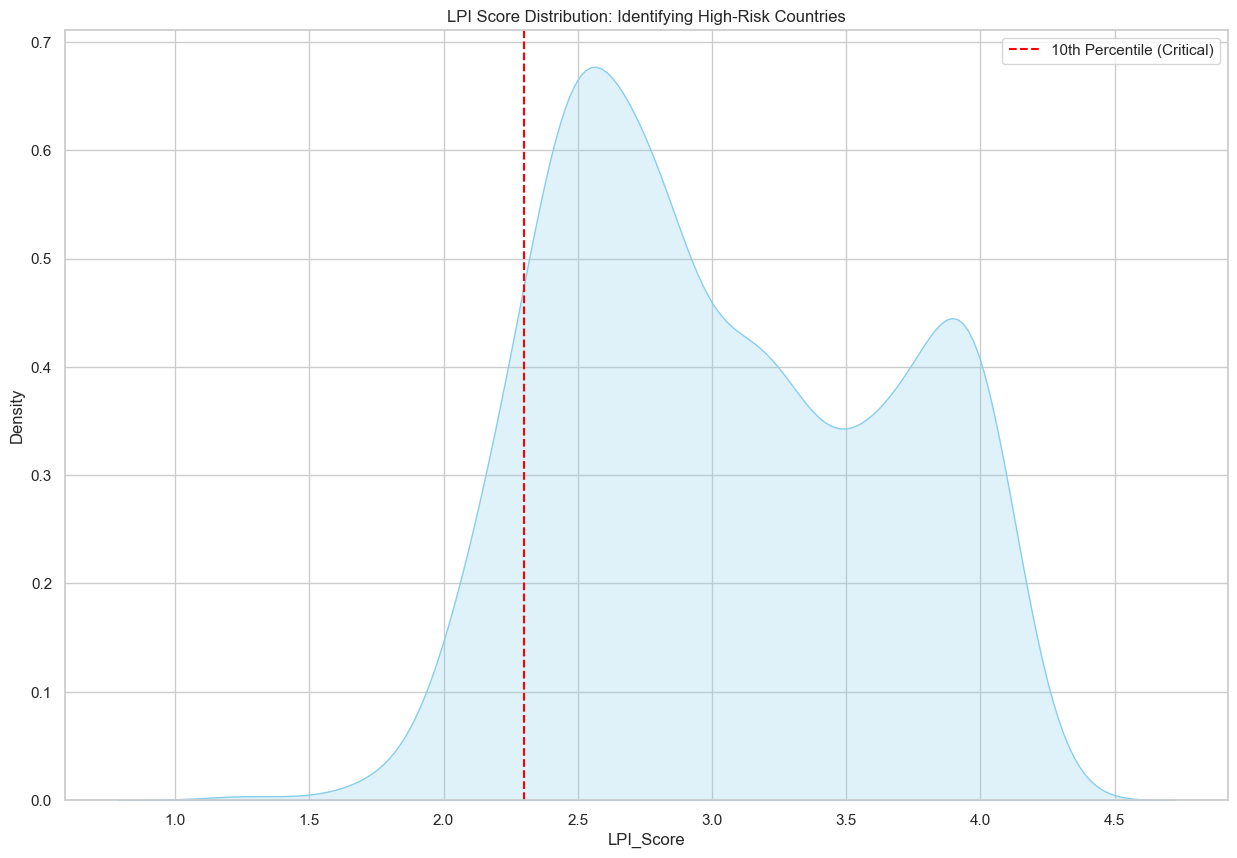

In [23]:
plt.figure()
sns.kdeplot(data=df_macro_index_view, x='LPI_Score', fill=True, color="skyblue")
plt.axvline(df_macro_index_view['LPI_Score'].quantile(0.10), color='red', linestyle='--', label='10th Percentile (Critical)')
plt.title('LPI Score Distribution: Identifying High-Risk Countries')
plt.legend()
plt.savefig('lpi_distribution.png')

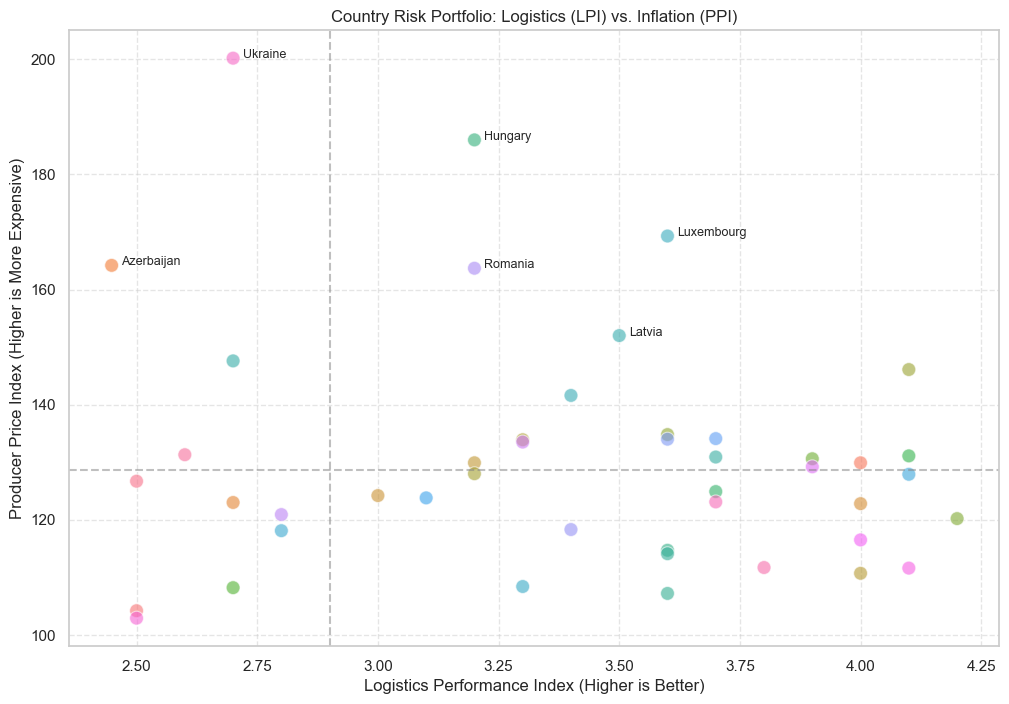

In [24]:


# We aggregate the macro data to get one bubble per country for the latest year (e.g., 2023)
# We assume 'Exposure' is the count of occurrences in your dataset for this example
df_plot = df_macro_index_view[df_macro_index_view['Year'] == 2023].copy()
df_plot['Exposure'] = df_plot.groupby('Country')['Country'].transform('count')

plt.figure(figsize=(12, 8))

# Create the bubble chart
bubble = sns.scatterplot(
    data=df_plot.dropna(subset=['LPI_Score', 'PPI_Value']),
    x='LPI_Score', 
    y='PPI_Value',
    size='Exposure',
    hue='Country',  # Or 'Region' if you have that column
    sizes=(100, 2000), # Adjust bubble size range
    alpha=0.6,
    legend=False
)

# Label the top risk countries manually for the thesis
for i in range(df_plot.shape[0]):
    # Label if LPI is very low or PPI is very high (The Red Zone)
    if df_plot.LPI_Score.iloc[i] < 2.5 or df_plot.PPI_Value.iloc[i] > 150:
        plt.text(
            df_plot.LPI_Score.iloc[i]+0.02, 
            df_plot.PPI_Value.iloc[i]+0.02, 
            df_plot.Country.iloc[i], 
            fontsize=9
        )

plt.title('Country Risk Portfolio: Logistics (LPI) vs. Inflation (PPI)')
plt.xlabel('Logistics Performance Index (Higher is Better)')
plt.ylabel('Producer Price Index (Higher is More Expensive)')
plt.grid(True, linestyle='--', alpha=0.5)

# Add quadrants
plt.axvline(x=df_plot['LPI_Score'].median(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=df_plot['PPI_Value'].median(), color='grey', linestyle='--', alpha=0.5)



# Labeling with Snorkel

In [29]:
df_final_no_spend['contracts_per_supplier'] = df_final_no_spend.groupby('supplier_id')['contract_id'].transform('nunique')

In [33]:
# 1. Define Labels
NEGOTIATE = 1
STABLE = 0
ABSTAIN = -1

# 2. Define the Functions (Ensuring names match the list below)
@labeling_function()
def lf_outdated_perpetual(x):
    if x.term_type == 'perpetual' and x.contract_age_years > 5:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_multiple_contracts(x):
    # Note: ensure 'contracts_per_supplier' is calculated in your df first
    if x.contracts_per_supplier > 4:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_unfavorable_payment_terms(x):
    short_terms = ['F030', 'L030', 'L015', 'N000']
    if any(term in str(x.payment_terms) for term in short_terms):
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_market_condition_change(x):
    if x.PPI_Value > 146 or x.LPI_Score < 3.8:
        return NEGOTIATE
    return ABSTAIN

@labeling_function()
def lf_financial_shock(x):
    if x.vol_shock_ratio > 10:
        return NEGOTIATE
    return ABSTAIN

In [37]:
lfs = [
    lf_outdated_perpetual, 
    lf_multiple_contracts, 
    lf_unfavorable_payment_terms, 
    lf_market_condition_change, 
    lf_financial_shock
]

applier = PandasLFApplier(lfs=lfs)
# FIX: use 'df=' as the parameter name
L_train = applier.apply(df=df_final_no_spend)

# 4. Train the Snorkel LabelModel
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(L_train=L_train, n_epochs=500, log_freq=100, seed=123)

# 5. Generate the Final Labels
# Probability of "NEGOTIATE"
df_final_no_spend['renegotiation_prob'] = label_model.predict_proba(L=L_train)[:, 1]

# Hard label (0 or 1)
df_final_no_spend['target_renegotiate'] = label_model.predict(L=L_train, tie_break_policy="abstain")

# FIX: Ensure print uses the correct dataframe name
print(df_final_no_spend[['contract_name', 'renegotiation_prob', 'target_renegotiate']].head())

100%|██████████| 9201/9201 [00:00<00:00, 38226.04it/s]
INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|          | 1/500 [00:00<01:03,  7.91epoch/s]INFO:root:[100 epochs]: TRAIN:[loss=0.003]
INFO:root:[200 epochs]: TRAIN:[loss=0.001]
INFO:root:[300 epochs]: TRAIN:[loss=0.001]
INFO:root:[400 epochs]: TRAIN:[loss=0.000]
100%|██████████| 500/500 [00:00<00:00, 2766.38epoch/s]
INFO:root:Finished Training


                 contract_name  renegotiation_prob  target_renegotiate
0  Bioreliance_Master_2018_MSA            0.374397                   0
1  Bioreliance_Master_2018_MSA            0.374397                   0
2  Bioreliance_Master_2018_MSA            0.374397                   0
3  Bioreliance_Master_2018_MSA            0.374397                   0
4  Bioreliance_Master_2018_MSA            0.374397                   0


In [38]:
df_final_no_spend.head()

,contract_id,observation_year,contract_number,contract_name,contract_status,terminated,term_type,start_date,expiration_date,supplier_id,...,PPI_Value,Customs,Infrastructure,International_Shipments,Logistics_Competence,Tracking_Tracing,Timeliness,contracts_per_supplier,renegotiation_prob,target_renegotiate
0,9675,2018,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
1,9675,2019,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
2,9675,2020,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
3,9675,2021,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
4,9675,2022,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0


In [40]:
df_final_no_spend.to_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv")

--- Label Distribution ---
target_renegotiate
 1    0.504836
 0    0.323334
-1    0.171829
Name: proportion, dtype: float64


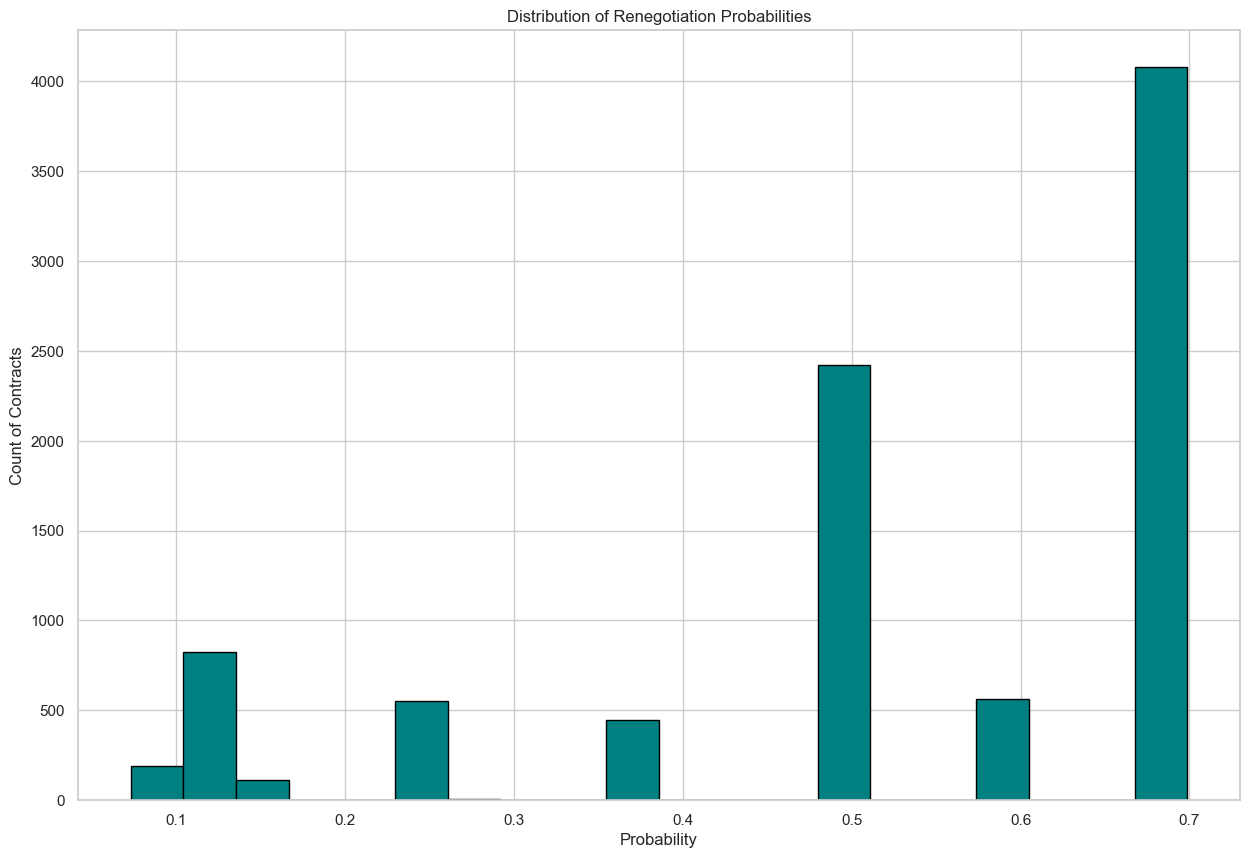

In [39]:
print("--- Label Distribution ---")
print(df_final_no_spend['target_renegotiate'].value_counts(normalize=True))

# Also check the spread of probabilities
import matplotlib.pyplot as plt
df_final_no_spend['renegotiation_prob'].hist(bins=20, color='teal', edgecolor='black')
plt.title("Distribution of Renegotiation Probabilities")
plt.xlabel("Probability")
plt.ylabel("Count of Contracts")
plt.show()

# XGBoost

/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_17605/446407837.py:8: DtypeWarning: Columns (0: terminated, 1: supplier_number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv")


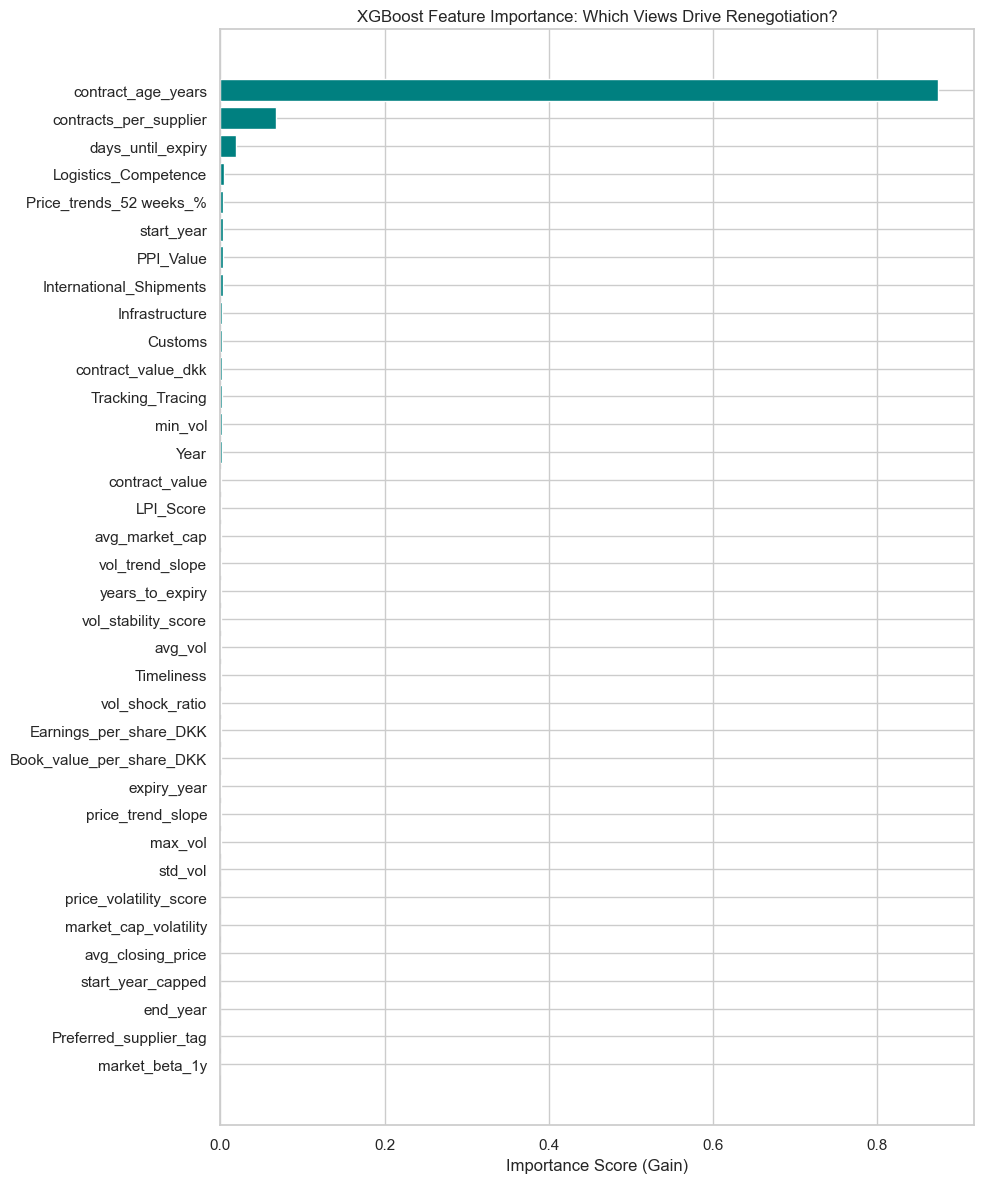

Suggested for elimination (Importance < 0.001):
['market_beta_1y', 'Preferred_supplier_tag', 'end_year', 'start_year_capped', 'avg_closing_price', 'market_cap_volatility', 'price_volatility_score', 'std_vol', 'max_vol', 'price_trend_slope', 'expiry_year', 'Book_value_per_share_DKK', 'Earnings_per_share_DKK', 'vol_shock_ratio', 'Timeliness', 'avg_vol', 'vol_stability_score']


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Load your labeled data
# Assuming you saved the output from the Snorkel step
df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv") 

# 2. Pre-calculate the 'Consolidation' helper if not already there
df['contracts_per_supplier'] = df.groupby('supplier_id')['contract_id'].transform('nunique')

# 3. Select Numeric Features from your 5 Views
# We exclude IDs, text, and the labels themselves
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_list = [
    'contract_id', 'supplier_id', 'observation_year', 'renegotiation_prob', 
    'target_renegotiate', 'Unnamed: 0', '_c0', 'contract_number', 'supplier_number'
]
X_features = [c for c in numeric_cols if c not in exclude_list]

# 4. Prepare X and y
# We use 'renegotiation_prob' as the target (Regression) because it contains 
# more information than the 0/1 hard label.
X = df[X_features]
y = df['renegotiation_prob']

# 5. Initialize and Train XGBoost Regressor
# We use a regressor since our target is a probability (0.0 to 1.0)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    importance_type='gain' # 'gain' is the most relevant for feature elimination
)

model.fit(X, y)

# 6. Extract and Plot Importance
importance_df = pd.DataFrame({
    'feature': X_features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True) # Ascending for the horizontal plot

# 7. Visualization
plt.figure(figsize=(10, 12))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.title("XGBoost Feature Importance: Which Views Drive Renegotiation?")
plt.xlabel("Importance Score (Gain)")
plt.tight_layout()
plt.show()

# 8. Identify the 'Junk' features for removal
low_importance_threshold = 0.001
junk_features = importance_df[importance_df['importance'] < low_importance_threshold]['feature'].tolist()
print(f"Suggested for elimination (Importance < {low_importance_threshold}):")
print(junk_features)